In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# import copy
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import numpy as np
from tqdm import tqdm

# Project Imports
sys.path.append('..')
from src.model import CNN
from src.utility.config import DEVICE, EXPERIMENT_CONFIGS, BASELINE_MODEL_PATH, QUANTIZED_MODELS
from src.utility.utils import get_data_loaders
# from src.utility.quantization_calibration import calibrate_model
# from src.utility.quantizer import Quantization
from src.layers import QuantizedLayerMixin

In [2]:
def calculate_sqnr(original, quantized):
    """Calculates Signal-to-Quantization-Noise Ratio."""
    noise = original - quantized
    signal_power = torch.mean(original**2)
    noise_power = torch.mean(noise**2)
    # Higher is better (less noise)
    return 10 * torch.log10(signal_power / (noise_power + 1e-10)).item()

def calculate_kl_divergence(baseline_logits, quant_logits):
    """Measures how much the probability distribution shifted."""
    p = F.softmax(baseline_logits, dim=1)
    log_q = F.log_softmax(quant_logits, dim=1)
    # Lower is better (distributions are similar)
    return F.kl_div(log_q, p, reduction='batchmean').item()

activation_storage = {"baseline": {}, "quantized": {}}

def get_hook(name, storage_dict):
    def hook(model, input, output):
        storage_dict[name] = output.detach()
    return hook

In [ ]:
_, test_loader, num_classes = get_data_loaders()

# Load Baseline
baseline_model = CNN(num_classes=num_classes).to(DEVICE)
baseline_model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=DEVICE))
baseline_model.eval()

# Metrics storage
all_results = []

for config in EXPERIMENT_CONFIGS:
    model_name = config['name']
    model_path = os.path.join(QUANTIZED_MODELS, f"model_{model_name}.pt")
    
    if not os.path.exists(model_path):
        print(f"Skipping {model_name}: File not found at {model_path}")
        continue
        
    print(f"Loading and Evaluating: {model_name}...")
    
    # Initialize a new model shell and load saved state
    model_q = CNN(num_classes=num_classes).to(DEVICE)
    # Important: Prepare the shell for quantization attributes before loading state
    model_q.convert_to_quantized(method=config['method'], bits=config['bits'])
    model_q.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model_q.eval()
    
    # Metric accumulators
    total_sqnr = 0
    total_kl = 0
    total_mse = 0
    correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            out_b = baseline_model(images)
            out_q = model_q(images)
            
            # Fidelity Metrics
            total_mse += F.mse_loss(out_b, out_q).item()
            total_sqnr += calculate_sqnr(out_b, out_q)
            total_kl += calculate_kl_divergence(out_b, out_q)
            
            # Traditional Accuracy
            pred = out_q.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total_samples += labels.size(0)

    # Average metrics over batches
    num_batches = len(test_loader)
    all_results.append({
        "Config": model_name,
        "Method": config['method'],
        "Bits": config['bits'],
        "Accuracy (%)": 100 * correct / total_samples,
        "Avg_MSE": total_mse / num_batches,
        "Avg_SQNR (dB)": total_sqnr / num_batches,
        "KL_Div": total_kl / num_batches,
        "Model_Size_MB": os.path.getsize(model_path) / (1024*1024)
    })

Loading and Evaluating: Sym_INT8...


Loading and Evaluating: Sym_INT4...


Loading and Evaluating: Aff_INT8...


Loading and Evaluating: Aff_INT4...


Loading and Evaluating: Po2_INT8...


Loading and Evaluating: Po2_INT4...


,Config,Method,Bits,Accuracy (%),Avg_MSE,Avg_SQNR (dB),KL_Div,Model_Size_MB
1,Sym_INT4,symmetric,4,20.59,9.292649e+12,-114.924843,1.504898e+06,1.40701
0,Sym_INT8,symmetric,8,17.92,3.808713e+28,-271.056513,1.690331e+14,1.40701
4,Po2_INT8,power2,8,17.36,8.374369e+28,-274.478153,2.444255e+14,1.40701
5,Po2_INT4,power2,4,16.43,1.815292e+13,-117.838251,3.514187e+06,1.40701
3,Aff_INT4,affine,4,10.00,inf,-inf,8.838704e+18,1.40701
2,Aff_INT8,affine,8,10.00,inf,-inf,1.807341e+26,1.40701


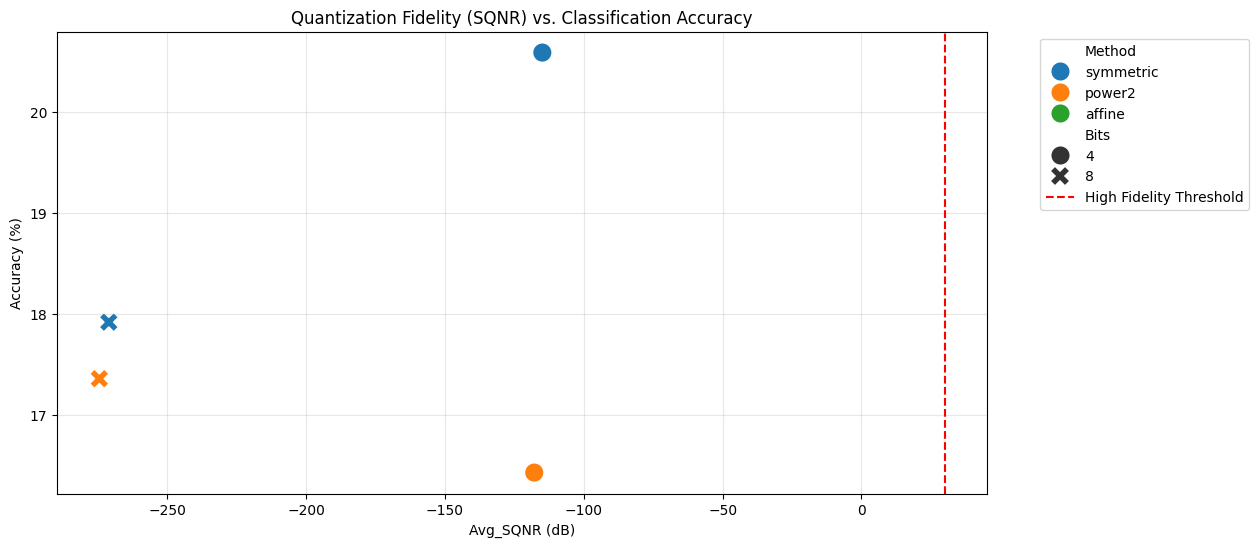

In [4]:
df = pd.DataFrame(all_results)
df = df.sort_values(by="Accuracy (%)", ascending=False)

# Display Table
display(df)

# Plot: Accuracy vs Noise (SQNR)
plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(
    data=df, 
    x="Avg_SQNR (dB)", 
    y="Accuracy (%)", 
    hue="Method", 
    style="Bits", 
    s=200
)
plt.title("Quantization Fidelity (SQNR) vs. Classification Accuracy")
plt.axvline(x=30, color='r', linestyle='--', label='High Fidelity Threshold') # 30dB is a common benchmark
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

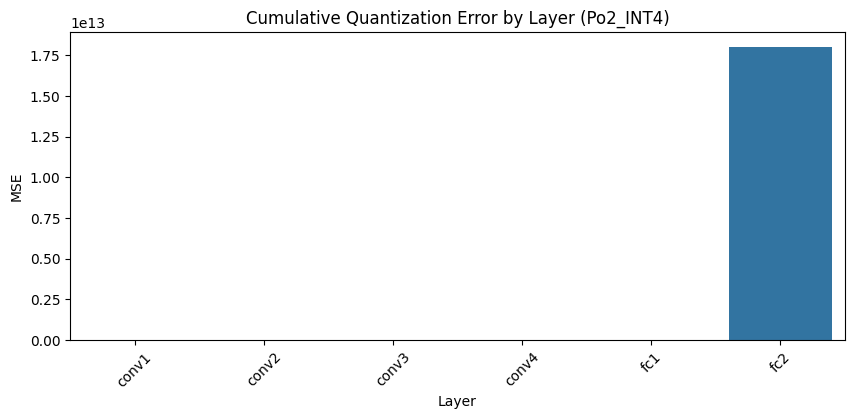

In [5]:
def analyze_layer_errors(baseline, quantized, dataloader):
    """Compare intermediate outputs of each layer."""
    layer_errors = []
    
    # We use a single batch for this deep dive
    images, _ = next(iter(dataloader))
    images = images.to(DEVICE)
    
    # Dictionary to store activations
    act_b = {}
    act_q = {}
    
    def get_hook(name, storage):
        def hook(m, i, o): storage[name] = o.detach()
        return hook
    
    hooks = []
    for name, module in baseline.named_modules():
        if isinstance(module, QuantizedLayerMixin):
            hooks.append(module.register_forward_hook(get_hook(name, act_b)))
            
    for name, module in quantized.named_modules():
        if isinstance(module, QuantizedLayerMixin):
            hooks.append(module.register_forward_hook(get_hook(name, act_q)))
            
    # Forward Pass
    baseline(images)
    quantized(images)
    
    # Cleanup
    for h in hooks: h.remove()
    
    # Calculate MSE per layer
    for name in act_b.keys():
        mse = F.mse_loss(act_b[name], act_q[name]).item()
        layer_errors.append({"Layer": name, "MSE": mse})
        
    return pd.DataFrame(layer_errors)

# Example: Analyze the last evaluated model
error_df = analyze_layer_errors(baseline_model, model_q, test_loader)
plt.figure(figsize=(10, 4))
sns.barplot(data=error_df, x="Layer", y="MSE")
plt.title(f"Cumulative Quantization Error by Layer ({model_name})")
plt.xticks(rotation=45)
plt.show()